In [29]:
import keras
import matplotlib
import numpy as np

In [30]:
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import InputLayer, Dense, Flatten, Dropout, Conv2D, MaxPooling2D, BatchNormalization
from tensorflow.keras import utils as np_utils
import matplotlib.pyplot as plt

In [ ]:
(x_train, y_train), (x_teste, y_teste) = mnist.load_data()
# carrega os dados das imagens

In [ ]:
x_train.shape, x_teste.shape
# tamanho das imagens, 28 por 28 pixels

((60000, 28, 28), (10000, 28, 28))

In [33]:
28 * 28

784

In [34]:
x_train, x_train.max()

(array([[[0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         ...,
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0]],
 
        [[0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         ...,
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0]],
 
        [[0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         ...,
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0]],
 
        ...,
 
        [[0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         ...,
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0]],
 
        [[0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],

In [35]:
y_train

array([5, 0, 4, ..., 5, 6, 8], shape=(60000,), dtype=uint8)

Text(0.5, 1.0, 'Classe 5')

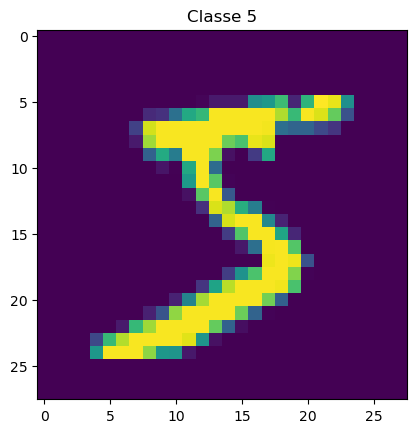

In [ ]:
plt.imshow(x_train[0])
plt.title('Classe '+str(y_train[0]))
# teste para ver a imagem

In [ ]:
x_train = x_train.reshape(x_train.shape[0], 28,28, 1)
# reformata para ter somente uma saida, no caso da imagem ser cinza os numeros de rgb sao iguais entao so precisa de uma imagem

In [ ]:
x_teste = x_teste.reshape(x_teste.shape[0], 28,28, 1)
# faz o mesmo para os dados de teste

In [39]:
x_train.shape, x_teste.shape

((60000, 28, 28, 1), (10000, 28, 28, 1))

In [ ]:
x_train = x_train.astype('float32')
# transforma em float para fazer a divisao por 255

In [41]:
x_teste = x_teste.astype('float32')

In [ ]:
x_train /=255
# transforma os pixels para 0-1 para a rede ficar mais leve
x_teste /=255

In [43]:
x_train.max(), x_train.min()

(np.float32(1.0), np.float32(0.0))

In [44]:
y_train

array([5, 0, 4, ..., 5, 6, 8], shape=(60000,), dtype=uint8)

In [ ]:
y_train = np_utils.to_categorical(y_train,10)
# transforma os numeros e categorias independentes, com um codigo para cada uma, isso pr conta das entradas da rede
y_teste = np_utils.to_categorical(y_teste,10)

In [46]:
y_train

array([[0., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 1., 0.]], shape=(60000, 10))

In [47]:
y_train[0]

array([0., 0., 0., 0., 0., 1., 0., 0., 0., 0.])

In [ ]:
rede_neural = Sequential()
rede_neural.add(InputLayer(shape=(28,28,1)))
# entrada da rede recebe a dimensao da imagem
rede_neural.add(Conv2D(filters=32, kernel_size=(3,3),activation='relu'))
# operador de convolução que fara a extração das principais caracteristicas
rede_neural.add(MaxPooling2D(pool_size=(2,2)))
# pega em as principais caracteristicas
rede_neural.add(Flatten())
# transform a em vetor a matriz depois do pooling
rede_neural.add(Dense(units=128,activation='relu'))
# camada oculta com 128 neuronios
rede_neural.add(Dense(units=10,activation='softmax'))
# saida com 10 classes

In [49]:
rede_neural.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 5408)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       692,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 693,962 (2.65 MB)

 Trainable params: 693,962 (2.65 MB)

 Non-trainable params: 0 (0.00 B)

In [50]:
rede_neural.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

In [ ]:
rede_neural.fit(x_train,y_train,batch_size=128, epochs=5,validation_data=(x_teste,y_teste))
# treina o modelo de rede neural

Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 11s 22ms/step - accuracy: 0.9380 - loss: 0.2170 - val_accuracy: 0.9769 - val_loss: 0.0730
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 11s 23ms/step - accuracy: 0.9802 - loss: 0.0667 - val_accuracy: 0.9812 - val_loss: 0.0603
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - accuracy: 0.9865 - loss: 0.0456 - val_accuracy: 0.9837 - val_loss: 0.0466
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 11s 23ms/step - accuracy: 0.9894 - loss: 0.0348 - val_accuracy: 0.9818 - val_loss: 0.0551
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 11s 23ms/step - accuracy: 0.9926 - loss: 0.0252 - val_accuracy: 0.9869 - val_loss: 0.0368


In [ ]:
resultado = rede_neural.evaluate(x_teste,y_teste)
# mede o quao bem foi o modelo com os dados de teste

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9869 - loss: 0.0368


In [53]:
resultado

[0.03684920817613602, 0.9868999719619751]